In [5]:
# imports
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from prophet import Prophet
except:
    from prophet import Prophet

plt.style.use("default")

sns.set_context("talk")


In [3]:
pip install prophet



   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.1 MB 6.3 MB/s eta 0:00:02
   ------ --------------------------------- 1.8/12.1 MB 4.0 MB/s eta 0:00:03
   -------- ------------------------------- 2.6/12.1 MB 4.0 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/12.1 MB 3.6 MB/s eta 0:00:03
   ------------ --------------------------- 3.9/12.1 MB 3.7 MB/s eta 0:00:03
   --------------- ------------------------ 4.7/12.1 MB 3.6 MB/s eta 0:00:03
   ------------------ --------------------- 5.5/12.1 MB 3.7 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.1 MB 3.7 MB/s eta 0:00:02
   ------------------------ --------------- 7.3/12.1 MB 3.7 MB/s eta 0:00:02
   -------------------------- ------------- 8.1/12.1 MB 3.8 MB/s eta 0:00:02
   ----------------------------- ---------- 8.9/12.1 MB 3.8 MB/s eta 0:00:01
   -------------------------------- ------- 9.7/12.1 MB 3.8 MB/s eta 0:00:01
   --

In [6]:
# load + clean
df = pd.read_csv("crop_yield_dataset.csv")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df = df[df['Crop_Yield'] > 0.19].sort_values('Date').reset_index(drop=True)
df.head()


,Date,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
0,2014-01-01,Corn,Loamy,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,104.871310,66.666667
1,2014-01-01,Barley,Sandy,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,58.939796,35.000000
2,2014-01-01,Soybean,Peaty,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,32.970413,22.166667
3,2014-01-01,Cotton,Sandy,6.75,14.826739,80.000000,10.366657,55.0,44.0,36.0,29.356115,39.375000
4,2014-01-01,Tomato,Clay,6.25,18.323272,80.000000,8.198084,60.0,45.0,40.0,22.221375,42.291667


In [ ]:
# weekly resample
df2 = df[['Date','Crop_Yield','Soil_pH','Temperature','Humidity','Wind_Speed','N','P','K','Soil_Quality']].copy()
df2.set_index('Date', inplace=True)
df_week = df2.resample('W-MON').mean().dropna()
df_week.head()


,Crop_Yield,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Soil_Quality
Date,,,,,,,,,
2014-01-06,37.419831,6.583333,17.407600,79.334204,10.095590,65.522222,53.144444,42.600000,39.587963
2014-01-13,34.325549,6.700000,16.774090,79.456855,9.622427,66.110000,53.110000,41.780000,37.846667
2014-01-20,35.308247,6.468750,17.141651,79.364187,9.639885,66.125000,53.531250,42.562500,39.810764
2014-01-27,38.337602,6.731132,16.860969,79.314441,10.145724,64.962264,52.867925,41.716981,40.544025
2014-02-03,38.783423,6.636364,17.615408,79.193527,9.571371,65.363636,52.654545,41.336364,38.433333


ADF: -5.693473007909161 p: 7.972218874663231e-07


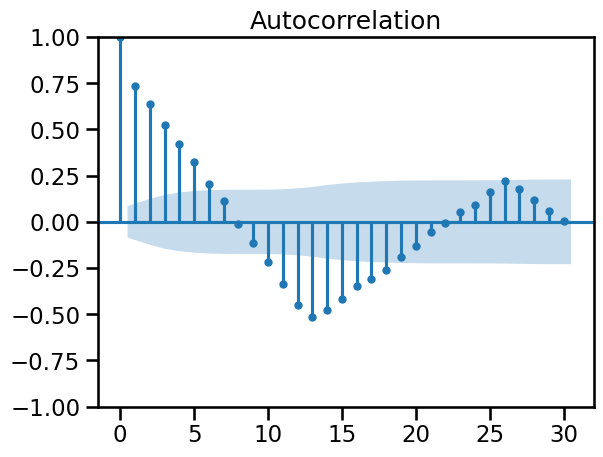

In [8]:
# stationarity + acf
s = df_week['Crop_Yield']
adf = adfuller(s)
print("ADF:", adf[0], "p:", adf[1])
plot_acf(s, lags=30)
plt.show()


In [9]:
# split
split = int(len(df_week)*0.8)
train, test = df_week.iloc[:split], df_week.iloc[split:]
train.shape, test.shape


((417, 9), (105, 9))

In [10]:
# arima + sarimax
arima = ARIMA(train['Crop_Yield'], order=(1,0,1)).fit()
arima_f = arima.forecast(len(test))

sarima = SARIMAX(train['Crop_Yield'], order=(1,0,1), seasonal_order=(1,0,1,52)).fit(disp=False)
sarima_f = sarima.forecast(len(test))

def mets(y, p):
    return mean_absolute_error(y,p), np.sqrt(mean_squared_error(y,p))

arima_m = mets(test['Crop_Yield'], arima_f)
sarima_m = mets(test['Crop_Yield'], sarima_f)

arima_m, sarima_m


((6.521190398295528, 7.937633202971672),
 (3.1617547872034897, 4.33965617086726))

In [11]:
# prophet
p_df = train.reset_index().rename(columns={'Date':'ds','Crop_Yield':'y'})
pm = Prophet(yearly_seasonality=True)
pm.fit(p_df)

future = test.reset_index().rename(columns={'Date':'ds'})[['ds']]
p_pred = pm.predict(future)['yhat'].values

p_m = mets(test['Crop_Yield'].values, p_pred)
p_m


00:14:23 - cmdstanpy - INFO - Chain [1] start processing
00:14:23 - cmdstanpy - INFO - Chain [1] done processing


(2.899708596236229, 3.7244924359667175)

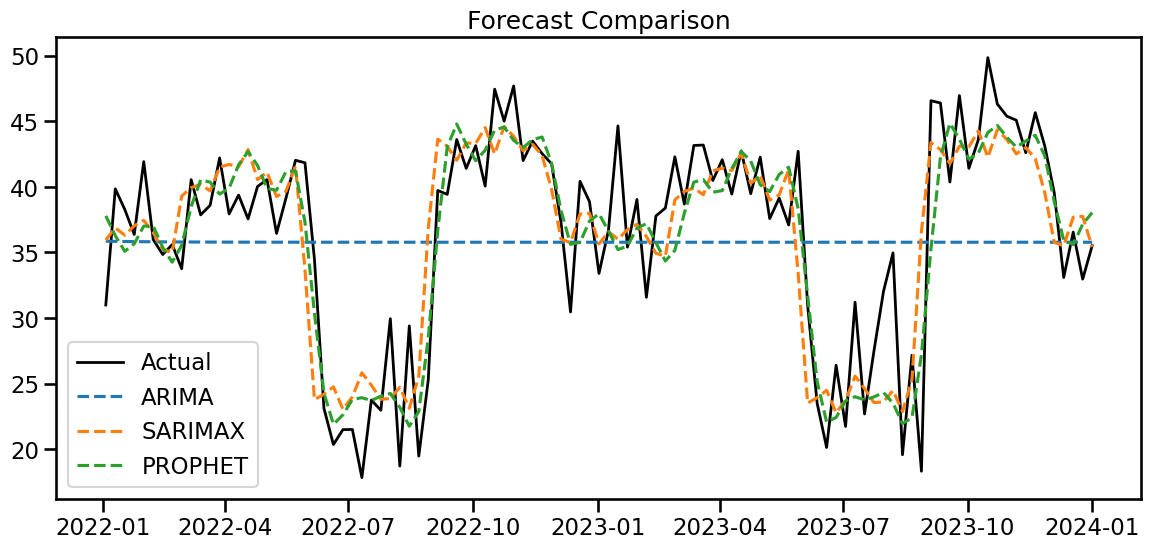

,Model,MAE,RMSE
0,ARIMA,6.521190,7.937633
1,SARIMAX,3.161755,4.339656
2,PROPHET,2.899709,3.724492


In [12]:
# compare + plot
res = pd.DataFrame({
    "Actual": test['Crop_Yield'].values,
    "ARIMA": arima_f.values,
    "SARIMAX": sarima_f.values,
    "PROPHET": p_pred
}, index=test.index)

plt.figure(figsize=(14,6))
plt.plot(res.index, res["Actual"], label="Actual", lw=2, color="black")
plt.plot(res.index, res["ARIMA"], "--", label="ARIMA")
plt.plot(res.index, res["SARIMAX"], "--", label="SARIMAX")
plt.plot(res.index, res["PROPHET"], "--", label="PROPHET")
plt.legend(); plt.title("Forecast Comparison")
plt.show()

pd.DataFrame({
    "Model":["ARIMA","SARIMAX","PROPHET"],
    "MAE":[arima_m[0], sarima_m[0], p_m[0]],
    "RMSE":[arima_m[1], sarima_m[1], p_m[1]]
})


In [13]:
# save comparison
res.to_csv("ms2_weekly_forecasts.csv")
print("saved ms2_weekly_forecasts.csv")


saved ms2_weekly_forecasts.csv
